#  Linear & Polynomial Regression on Real Data Project

> **Overview**
>
> This project applies Linear and Polynomial Regression to the California Housing dataset. It covers data exploration, model building from scratch, optimization using Gradient Descent and its variants, and comparison with professional machine learning libraries.

<details>
<summary><strong>Topics Covered</strong></summary>

- California Housing Dataset
- Data Exploration & Correlation Analysis
- Linear Regression
- Polynomial Regression
- Mean Squared Error (MSE)
- Gradient Descent
- Batch, SGD & Mini-Batch Gradient Descent
- Momentum
- RMSProp
- Adam Optimizer
- Model Evaluation
- Scikit-learn & PyTorch Implementation

</details>

# Part 1 : Loading Real Data
**What's in this dataset?**
- **20,640 houses** in California
- **8 features** like income, house age, number of rooms
- **Target:** Median house price

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D

import torch
import torch.nn as nn
import torch.optim as optim

print("All libraries imported successfully!")
print("PyTorch version:", torch.__version__)

All libraries imported successfully!
PyTorch version: 2.13.0+cpu


In [4]:
# Load the California Housing dataset
california=fetch_california_housing()

# Extract features (X) and target (y)
X=california.data
y=california.target

# Get feature names
feature_names=california.feature_names

print("Dataset loaded successfully!")
print(f"\nNumber of samples: {X.shape[0]:,}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature descriptions:")
print(f"  0: MedInc      - Median income in block group (in $10,000s)")
print(f"  1: HouseAge    - Median house age in block group (in years)")
print(f"  2: AveRooms    - Average number of rooms per household")
print(f"  3: AveBedrms   - Average number of bedrooms per household")
print(f"  4: Population  - Block group population")
print(f"  5: AveOccup    - Average number of household members")
print(f"  6: Latitude    - Block group latitude")
print(f"  7: Longitude   - Block group longitude")
print(f"\nTarget: Median house value (in $100,000s)")
print(f"\nExample: MedInc=3.5 means median income is $35,000")



Dataset loaded successfully!

Number of samples: 20,640
Number of features: 8

Feature descriptions:
  0: MedInc      - Median income in block group (in $10,000s)
  1: HouseAge    - Median house age in block group (in years)
  2: AveRooms    - Average number of rooms per household
  3: AveBedrms   - Average number of bedrooms per household
  4: Population  - Block group population
  5: AveOccup    - Average number of household members
  6: Latitude    - Block group latitude
  7: Longitude   - Block group longitude

Target: Median house value (in $100,000s)

Example: MedInc=3.5 means median income is $35,000


In [3]:
# Let's look at the first 5 samples
print("First 5 Houses \n")
for i in range(5):
    print(f"House {i+1} :")
    for j,name in enumerate(feature_names):
        print(f"  {name}: {X[i,j]}:.2f")
    print(f"   ->Price: ${y[i]*100000:,.0f}") 
print()



First 5 Houses 

House 1 :
  MedInc: 8.3252:.2f
  HouseAge: 41.0:.2f
  AveRooms: 6.984126984126984:.2f
  AveBedrms: 1.0238095238095237:.2f
  Population: 322.0:.2f
  AveOccup: 2.5555555555555554:.2f
  Latitude: 37.88:.2f
  Longitude: -122.23:.2f
   ->Price: $452,600
House 2 :
  MedInc: 8.3014:.2f
  HouseAge: 21.0:.2f
  AveRooms: 6.238137082601054:.2f
  AveBedrms: 0.9718804920913884:.2f
  Population: 2401.0:.2f
  AveOccup: 2.109841827768014:.2f
  Latitude: 37.86:.2f
  Longitude: -122.22:.2f
   ->Price: $358,500
House 3 :
  MedInc: 7.2574:.2f
  HouseAge: 52.0:.2f
  AveRooms: 8.288135593220339:.2f
  AveBedrms: 1.073446327683616:.2f
  Population: 496.0:.2f
  AveOccup: 2.8022598870056497:.2f
  Latitude: 37.85:.2f
  Longitude: -122.24:.2f
   ->Price: $352,100
House 4 :
  MedInc: 5.6431:.2f
  HouseAge: 52.0:.2f
  AveRooms: 5.8173515981735155:.2f
  AveBedrms: 1.0730593607305936:.2f
  Population: 558.0:.2f
  AveOccup: 2.547945205479452:.2f
  Latitude: 37.85:.2f
  Longitude: -122.25:.2f
   ->Pric

In [37]:
# Basic Statistics 
print("Feature Statistics: \n")
print(f"{'Feature':<15} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}") 
print("="*63)

for i, name in enumerate(feature_names):
    print(f"{name:<15} {np.mean(X[:, i]):<12.2f} {np.std(X[:, i]):<12.2f} "
          f"{np.min(X[:, i]):<12.2f} {np.max(X[:, i]):<12.2f}")

print(f"\n{'Target (Price)':<15} {np.mean(y):<12.2f} {np.std(y):<12.2f} "
      f"{np.min(y):<12.2f} {np.max(y):<12.2f}")



Feature Statistics: 

Feature         Mean         Std          Min          Max         
MedInc          3.87         1.90         0.50         15.00       
HouseAge        28.64        12.59        1.00         52.00       
AveRooms        5.43         2.47         0.85         141.91      
AveBedrms       1.10         0.47         0.33         34.07       
Population      1425.48      1132.43      3.00         35682.00    
AveOccup        3.07         10.39        0.69         1243.33     
Latitude        35.63        2.14         32.54        41.95       
Longitude       -119.57      2.00         -124.35      -114.31     

Target (Price)  2.07         1.15         0.15         5.00        


## Exploratory Data Analysis (EDA)
## Part 2: Correlation Analysis

In [65]:
# Calculate correlation of each feature with target
correlations=[]

for i,name in enumerate(feature_names):
     # Correlation formula: cov(X, y) / (std(X) * std(y))  ... remember that correlation is just normalised covariance
    corr=np.corrcoef(X[:,i],y)[0,1] 
    correlations.append(corr)

#np.argsort() returns the indices (positions) that would sort an array
sorted_indices=np.argsort(np.abs(correlations))[::-1] # to make desc sorting so index 0 refer to larges correlation

print("Features ranked by correlation with Price:\n")
print(f"{'Rank':<6} {'Feature':<15} {'Correlation':<12}")
print("="*35)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank+1:<6} {feature_names[idx]:<15} {correlations[idx]:>+11.3f}")


print(f"\nKey Insight: {feature_names[np.where(sorted_indices == 0)[0][0]]} has the strongest correlation!")



Features ranked by correlation with Price:

Rank   Feature         Correlation 
1      MedInc               +0.688
2      AveRooms             +0.152
3      Latitude             -0.144
4      HouseAge             +0.106
5      AveBedrms            -0.047
6      Longitude            -0.046
7      Population           -0.025
8      AveOccup             -0.024

Key Insight: MedInc has the strongest correlation!


# Visualize all Features Vs Target

Notice how MedInc (median income) shows the clearest positive correlation .. also notice how things are looking different when dealing with real data!


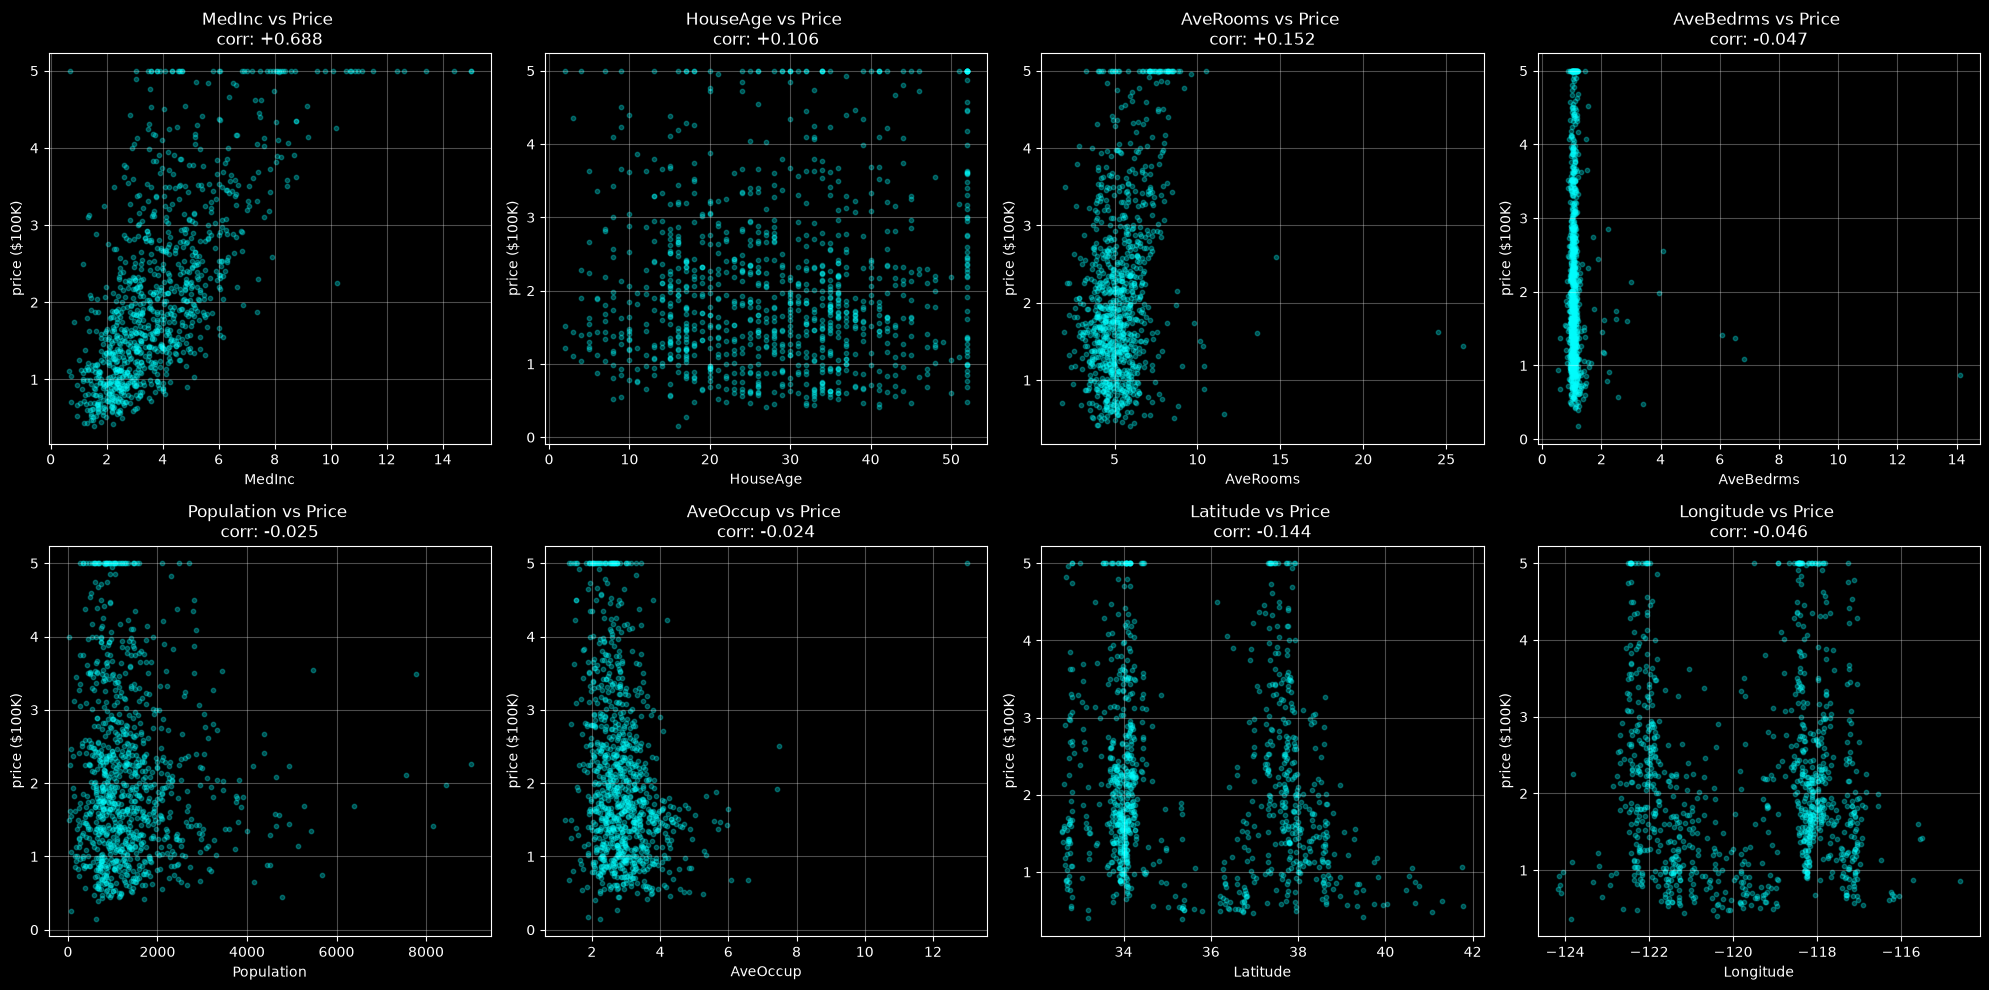

In [90]:

plt.style.use("dark_background")
fig ,axes = plt.subplots(2,4,figsize=(20,10))
axes=axes.flatten() # change axes from 2*4 matrix to vector of size 8

#zip() pairs the first element of each list together, then the second, and so on, and return each pair in tuple (x,y)
for idx, (axs,name) in enumerate(zip(axes,feature_names)):

    indices=np.random.choice(X.shape[0],1000,replace=False)# choose 100 random index from 20,000 sample and 100 random are diff

    axs.scatter(X[indices,idx],y[indices],c='cyan',alpha=0.3,s=10)
    axs.set_xlabel(name)
    axs.set_ylabel("price ($100K)")
    axs.set_title(f"{name} vs Price \ncorr: {correlations[idx]:+.3f}")
    axs.grid(alpha=0.3)

plt.tight_layout()
print("Notice how MedInc (median income) shows the clearest positive correlation .. also notice how things are looking different when dealing with real data!")



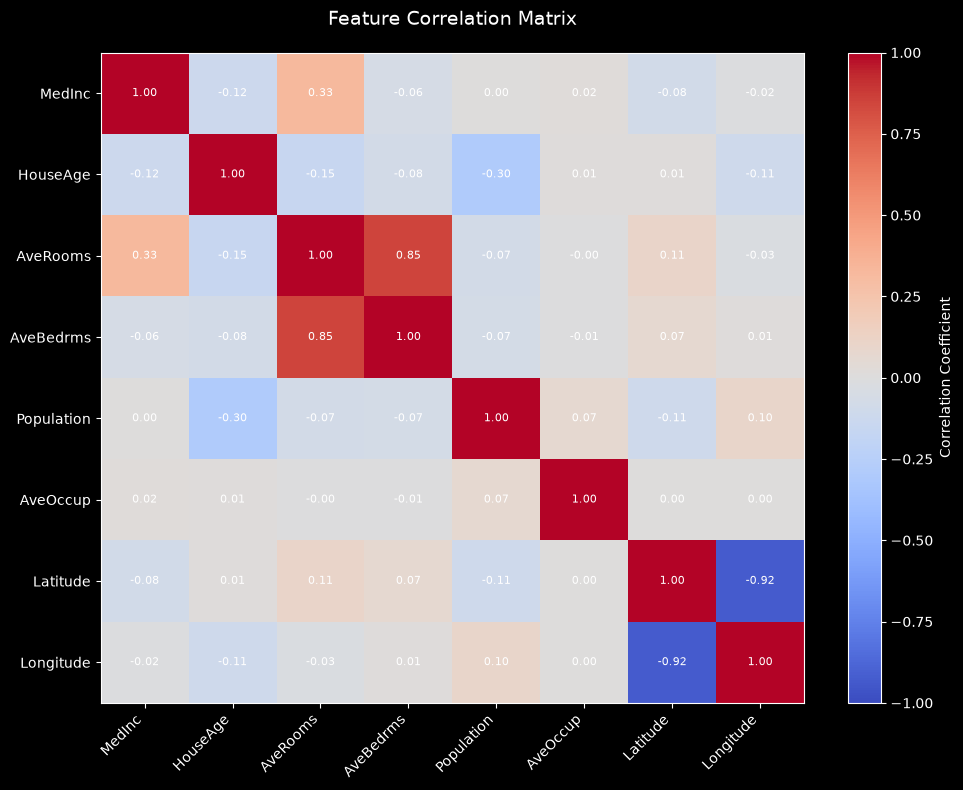

In [ ]:
# Correlation matrix heatmap
# Calculate correlation between all features
correlation_matrix = np.corrcoef(X.T)

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.yticks(range(len(feature_names)), feature_names)
plt.title('Feature Correlation Matrix', fontsize=14, pad=20)

# Add correlation values
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        plt.text(j, i, f'{correlation_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=8)

plt.tight_layout()
#MedInc (median income) has the strongest correlation with price (+0.688)
# AveRooms and AveBedrms are highly correlated (0.85) - makes sense!
# Features with stronger correlations will give better predictions

# Part 3 :Linear Regression From Scratch
We'll use **MedInc** (median income) as our feature since it has the strongest correlation.

**Rules**
- Model: `ŷ = w * x + b`
- Cost function (MSE): `J = (1/2m) * Σ(ŷ - y)²`
- Gradient descent updates:
  - `w = w - η * (1/m) * Σ(ŷ - y) * x`
  - `b = b - η * (1/m) * Σ(ŷ - y)`

In [ ]:
# Extract MedInc feature (feature 0)
x_medinc=X[:,0] 
y_price=y

print(f"Training Samples : {len(x_medinc):,}")
print(f"Feature: {feature_names[0]}")
print(f"Target: Median house value")


Training Samples : 20,640


In [124]:
np.random.seed(42)

w=np.random.rand()
b=np.random.rand()

learning_rate=0.01
epochs=1000
m=len(x_medinc)

cost_history=[]
print(f"Initial w: {w:.4f}")
print(f"Initial b: {b:.4f}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"\nStarting training...")

Initial w: 0.3745
Initial b: 0.9507
Learning rate: 0.01
Epochs: 1000

Starting training...


In [125]:
# Gradient Descent Training Loop

for epoch in range(epochs):

  y_hat_price=w*x_medinc+b

  dw=((y_hat_price-y_price)@ x_medinc) / m
  db=np.mean(y_hat_price-y_price)

  cost= np.mean((y_hat_price-y_price)**2)/2
  cost_history.append(cost)

  w=w-learning_rate*dw
  b=b-learning_rate*db

  if(epoch+1)%100 ==0 or epoch==0:
     print(f"Epoch {epoch+1:4d}: Cost = {cost:.4f}, w = {w:.4f}, b = {b:.4f}")
  epoch=epoch+1  


print(f"\nTraining complete!")
print(f"Final w: {w:.4f}")
print(f"Final b: {b:.4f}")
print(f"Final cost (MSE): {cost_history[-1]:.4f}")   


Epoch    1: Cost = 0.4090, w = 0.3633, b = 0.9474
Epoch  100: Cost = 0.3665, w = 0.3328, b = 0.8555
Epoch  200: Cost = 0.3616, w = 0.3473, b = 0.7868
Epoch  300: Cost = 0.3581, w = 0.3593, b = 0.7297
Epoch  400: Cost = 0.3558, w = 0.3693, b = 0.6823
Epoch  500: Cost = 0.3542, w = 0.3775, b = 0.6430
Epoch  600: Cost = 0.3530, w = 0.3844, b = 0.6104
Epoch  700: Cost = 0.3523, w = 0.3901, b = 0.5833
Epoch  800: Cost = 0.3517, w = 0.3948, b = 0.5608
Epoch  900: Cost = 0.3514, w = 0.3987, b = 0.5421
Epoch 1000: Cost = 0.3511, w = 0.4020, b = 0.5266

Training complete!
Final w: 0.4020
Final b: 0.5266
Final cost (MSE): 0.3511


# Visualize  Linear Regression 


Notice how the cost decreases smoothly - this is gradient descent working!
The red line shows our model's predictions.


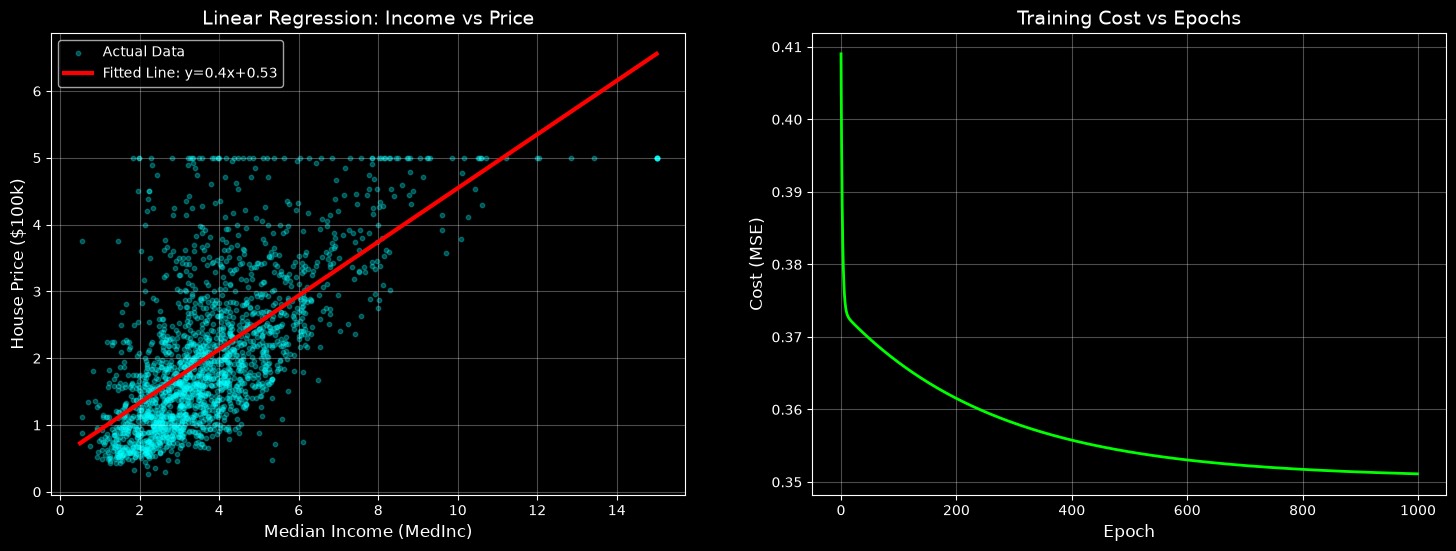

In [134]:

plt.figure(figsize=(18,6))

indices=np.random.choice(m,2000,replace=False)
plt.subplot(1,2,1)
plt.scatter(x_medinc[indices],y_price[indices],c='cyan',alpha=0.3,s=10,label="Actual Data")

x_axis=np.linspace(np.min(x_medinc),np.max(x_medinc),100)
y_axis=w*x_axis+b
plt.plot(x_axis,y_axis,c='r',lw=3,label=f"Fitted Line: y={w:.2}x+{b:.2}")
plt.xlabel('Median Income (MedInc)', fontsize=12)
plt.ylabel('House Price ($100k)', fontsize=12)
plt.title('Linear Regression: Income vs Price', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(cost_history,'lime',lw=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title('Training Cost vs Epochs', fontsize=14)
plt.grid(True, alpha=0.3)
print("\nNotice how the cost decreases smoothly - this is gradient descent working!")
print("The red line shows our model's predictions.")

In [135]:
# Make predictions on new data
test_incomes = np.array([2.0, 4.0, 6.0, 8.0])
test_predictions = w * test_incomes + b

print("Predictions on new data:\n")
for income, pred in zip(test_incomes, test_predictions):
    print(f"Median Income = {income:.1f} → Predicted Price = ${pred*100000:,.0f}")

print(f"\nInterpretation: For every $10,000 increase in median income, ")
print(f"house price increases by ${w*10000:,.0f} on average.")
# note how when we wanted to mention rate of change we didn't include the bias so we cared about the slope itself

Predictions on new data:

Median Income = 2.0 → Predicted Price = $133,063
Median Income = 4.0 → Predicted Price = $213,464
Median Income = 6.0 → Predicted Price = $293,865
Median Income = 8.0 → Predicted Price = $374,267

Interpretation: For every $10,000 increase in median income, 
house price increases by $4,020 on average.


## Part 4 : Polynomial Regression

 - fitting curves instead of straight lines.

**Linear:** `ŷ = w₁x + b`  
**Quadratic:** `ŷ = w₂x² + w₁x + b`  
**Cubic:** `ŷ = w₃x³ + w₂x² + w₁x + b`

## Part 5: Comparing Optimizers


**Types of Gradient Descent:**
1. **Batch GD** - Uses ALL data at once (what we did above)
2. **Stochastic GD (SGD)** - Uses ONE sample at a time
3. **Mini-batch GD** - Uses small batches of samples

**Advanced Optimizers :**

4. **Momentum**
5. **RMSprop**
6. **Adam**

In [148]:
n_samples=5000
X_train=X[:n_samples,0].reshape(-1,1) # make 1d vector to 2D column vector 
y_train=y[:n_samples]

print(f"Training with {n_samples} samples")
print(f"Feature: {feature_names[0]}")
print(f"\nWe'll compare 6 different optimizers!")

Training with 5000 samples
Feature: MedInc

We'll compare 6 different optimizers!


In [144]:
# 1. Batch Gradient Descent (from scratch) 
"""
    Standard batch gradient descent.
    Uses ALL samples in each iteration.
"""

def batch_gradient_descent(x,y,learning_rate=0.01,epochs=200):
    
    np.random.seed(42)
    w=np.random.rand()
    b=np.random.rand()
    m=len(x)
    costs=[]
    w_hist=[w]
    b_hist=[b]
  
    for epoch in range(epochs):

        y_hat =w*x+b    
        error=y_hat-y

        dw= error@x / m
        db=np.mean(error)

        w=w-learning_rate*dw
        b=b-learning_rate*db

        w_hist.append(w)
        b_hist.append(b)


        cost= np.sum(error**2)/2*m
        costs.append(cost)

    return costs,w_hist,b_hist    
print("Batch Gradient Descent function ready!")


Batch Gradient Descent function ready!


In [149]:
# Train all optimizers using PyTorch .. note how we do that with PyTorch and how we put our data in specific format for PyTorch
# it may seem a lot for now but when the models are complicated PyTorch is the go to.
# don't worry if you don't know all the steps right now because we will come to them many times with other models


# Convert data to PyTorch tensors
X_train_torch = torch.FloatTensor(X_train)
y_train_torch = torch.FloatTensor(y_train)

max_iter = 200
results = {}

print("Training optimizers with PyTorch...\n")

# Function to create and initialize model with same weights
def create_model():
    torch.manual_seed(42)  # Fix seed for reproducible initialization
    model = nn.Linear(1, 1) # Create a simple linear model: y = w * x + b
    # Initialize with same values for fair comparison
    nn.init.constant_(model.weight, 0.5)
    nn.init.constant_(model.bias, 0.5)
    return model

# Modified loss function to match our from-scratch (0.5 * MSE)
def custom_mse_loss(output, target):
    return 0.5 * torch.mean((output - target) ** 2)

# 1. Batch Gradient Descent (from scratch - reference)
print("1. Batch Gradient Descent (from scratch)...")
costs_batch, w_batch, b_batch = batch_gradient_descent(X_train, y_train,
                                                        learning_rate=0.01,
                                                        epochs=max_iter)
w_batch_3d = w_batch  # assign AFTER the function call
b_batch_3d = b_batch
results['Batch GD'] = costs_batch
print(f"   Final MSE: {costs_batch[-1]:.4f}")

# 2. SGD (Stochastic Gradient Descent)
print("\n2. Stochastic Gradient Descent (SGD)...")
model_sgd = create_model()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01) # Use PyTorch's built-in SGD optimizer
costs_sgd = []
w_history_sgd = [0.5]
b_history_sgd = [0.5]

for epoch in range(max_iter):
    # not how we have the main structure of applying the weights then computing gradients then updating the weights
    # but now we are doing this with PyTorch so we are not manually calculating them
    optimizer_sgd.zero_grad()
    outputs = model_sgd(X_train_torch) # Forward pass: predict prices from input feature
    loss = custom_mse_loss(outputs.squeeze(), y_train_torch) # Compute loss (0.5 * MSE)
    loss.backward() # Backpropagation: compute gradients
    optimizer_sgd.step() # Update parameters using gradients
    # Store loss and parameters for analysis
    costs_sgd.append(loss.item())
    w_history_sgd.append(model_sgd.weight.item())
    b_history_sgd.append(model_sgd.bias.item())

results['SGD'] = costs_sgd
print(f"   Final MSE: {costs_sgd[-1]:.4f}")

# 3. SGD with Momentum
print("\n3. SGD with Momentum...")
model_momentum = create_model()
optimizer_momentum = optim.SGD(model_momentum.parameters(), lr=0.01, momentum=0.9)
costs_momentum = []
w_history_momentum = [0.5]
b_history_momentum = [0.5]

for epoch in range(max_iter):
    optimizer_momentum.zero_grad()
    outputs = model_momentum(X_train_torch)
    loss = custom_mse_loss(outputs.squeeze(), y_train_torch)
    loss.backward()
    optimizer_momentum.step()
    costs_momentum.append(loss.item())
    w_history_momentum.append(model_momentum.weight.item())
    b_history_momentum.append(model_momentum.bias.item())

results['Momentum'] = costs_momentum
print(f"   Final MSE: {costs_momentum[-1]:.4f}")

# 4. RMSprop
print("\n4. RMSprop...")
model_rmsprop = create_model()
optimizer_rmsprop = optim.RMSprop(model_rmsprop.parameters(), lr=0.01)
costs_rmsprop = []
w_history_rmsprop = [0.5]
b_history_rmsprop = [0.5]

for epoch in range(max_iter):
    optimizer_rmsprop.zero_grad()
    outputs = model_rmsprop(X_train_torch)
    loss = custom_mse_loss(outputs.squeeze(), y_train_torch)
    loss.backward()
    optimizer_rmsprop.step()
    costs_rmsprop.append(loss.item())
    w_history_rmsprop.append(model_rmsprop.weight.item())
    b_history_rmsprop.append(model_rmsprop.bias.item())

results['RMSprop'] = costs_rmsprop
print(f"   Final MSE: {costs_rmsprop[-1]:.4f}")

# 5. Adam
print("\n5. Adam...")
model_adam = create_model()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.01)
costs_adam = []
w_history_adam = [0.5]
b_history_adam = [0.5]

for epoch in range(max_iter):
    optimizer_adam.zero_grad()
    outputs = model_adam(X_train_torch)
    loss = custom_mse_loss(outputs.squeeze(), y_train_torch)
    loss.backward()
    optimizer_adam.step()
    costs_adam.append(loss.item())
    w_history_adam.append(model_adam.weight.item())
    b_history_adam.append(model_adam.bias.item())

results['Adam'] = costs_adam
print(f"   Final MSE: {costs_adam[-1]:.4f}")

# 6. AdamW (Adam with weight decay (will talk about it later in lecture 8 but i want you to see it here as well))
print("\n6. AdamW...")
model_adamw = create_model()
optimizer_adamw = optim.AdamW(model_adamw.parameters(), lr=0.01)
costs_adamw = []
w_history_adamw = [0.5]
b_history_adamw = [0.5]

for epoch in range(max_iter):
    optimizer_adamw.zero_grad()
    outputs = model_adamw(X_train_torch)
    loss = custom_mse_loss(outputs.squeeze(), y_train_torch)
    loss.backward()
    optimizer_adamw.step()
    costs_adamw.append(loss.item())
    w_history_adamw.append(model_adamw.weight.item())
    b_history_adamw.append(model_adamw.bias.item())

results['AdamW'] = costs_adamw
print(f"   Final MSE: {costs_adamw[-1]:.4f}")

print("\n" + "="*50)
print("All optimizers trained with PyTorch!")
print("="*50)
print("\nNote: All optimizers start from the same initialization (w=0.5, b=0.5)")
print("This ensures a fair comparison of convergence behavior.")

# Store weight histories for 3D visualization
weight_histories = {
    'Batch GD': (w_batch_3d, b_batch_3d) if 'w_batch_3d' in locals() else (None, None),
    'SGD': (np.array(w_history_sgd), np.array(b_history_sgd)),
    'Momentum': (np.array(w_history_momentum), np.array(b_history_momentum)),
    'RMSprop': (np.array(w_history_rmsprop), np.array(b_history_rmsprop)),
    'Adam': (np.array(w_history_adam), np.array(b_history_adam)),
    'AdamW': (np.array(w_history_adamw), np.array(b_history_adamw))
}

Training optimizers with PyTorch...

1. Batch Gradient Descent (from scratch)...
   Final MSE: 80039672507.0767

2. Stochastic Gradient Descent (SGD)...
   Final MSE: 0.3159

3. SGD with Momentum...
   Final MSE: 0.3157

4. RMSprop...
   Final MSE: 0.3157

5. Adam...
   Final MSE: 0.3157

6. AdamW...
   Final MSE: 0.3157

All optimizers trained with PyTorch!

Note: All optimizers start from the same initialization (w=0.5, b=0.5)
This ensures a fair comparison of convergence behavior.
